Загружаем данные с текстами статей

In [ ]:
import pandas as pd
import re

In [ ]:
df = pd.read_csv("articles.csv")

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"&nbsp;|&#8233;|&amp;", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
df["article"] = df["article"].apply(clean_text)

In [ ]:
print(f"Всего текстов: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
print(f"\nПример:\n{df['article'].iloc[0][:300]}")

Всего текстов: 49
Колонки: ['article']

Пример:
63% россиян считают, что забота – это стремление сделать жизнь партнера проще, следует из опроса сервиса «Ясно», с которым ознакомился «Ведомости. Город». Для 58 % забота состоит из умения предугадывать потребности, для 44% – из эмоциональной связи. При этом проявлять заботу по их мнению наиболее ва


Установка библиотеки

In [ ]:
!pip install -q langextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.5 MB/s eta 0:00:00


In [ ]:
import langextract as lx
import importlib.metadata

print(f"LangExtract version: {importlib.metadata.version('langextract')}")

LangExtract version: 1.6.0


Установка Ollama и запуск сервера

In [ ]:
!apt-get update -qq && apt-get install -y -qq zstd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
Selecting previously unselected package zstd.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../zstd_1.5.5+dfsg2-2build1.1_amd64.deb ...
Unpacking zstd (1.5.5+dfsg2-2build1.1) ...
Setting up zstd (1.5.5+dfsg2-2build1.1) ...
Processing triggers for man-db (2.12.0-4build2) ...


In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
!nvidia-smi

Sun Sep 13 05:22:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import subprocess, time

subprocess.Popen(["ollama", "serve"])
time.sleep(5)

# Проверяем, что сервер отвечает
!curl -s http://localhost:11434/api/tags

{"models":[]}

Загружаем модель

In [ ]:
!ollama pull qwen2.5:7b

In [ ]:
!ollama list

NAME          ID              SIZE      MODIFIED       
qwen2.5:7b    845dbda0ea48    4.7 GB    20 seconds ago    


In [ ]:
# Патч: увеличиваем тайм-аут для Ollama
from functools import partialmethod
from langextract.inference import OllamaLanguageModel

OllamaLanguageModel._ollama_query = partialmethod(
    OllamaLanguageModel._ollama_query,
    timeout=600,
    keep_alive=0,
)

print("Патч применён: timeout=600, keep_alive=0")

Патч применён: timeout=600, keep_alive=0


Фиксируем промт

In [ ]:
# Финальный промпт v3
prompt = """
Ты — эксперт по синтаксическому разбору русских текстов.
Извлекай триплеты "субъект - предикат - объект" строго по грамматике.

ОБЯЗАТЕЛЬНЫЕ УСЛОВИЯ (если хотя бы одно не выполнено — триплет НЕ извлекается):

1. СУБЪЕКТ — существительное или местоимение в ИМЕНИТЕЛЬНОМ падеже.
   Действия, процессы и абстракции ("проявлять заботу", "внимание", "помощь") НЕ являются субъектами.
   Местоимения ("они", "он", "она") заменяй на сущность из предыдущего предложения.
   Восстанавливай пропущенные субъекты: "58%" -> "58% респондентов".

2. ПРЕДИКАТ — глагол в личной форме (считают, состоит, вырос, заявил).
   Безличные слова ("важно", "нужно", "необходимо") НЕ являются предикатами.
   Составное сказуемое ("это стремление", "является практикой") допустимо.
   Связка без глагола ("X — Y") извлекается только если Y это действие.

3. ОБЪЕКТ — дополнение или именная часть сказуемого.
   Числа и проценты БЕЗ существительного ("58%", "49%") НЕ являются объектами.
   Объект может быть длинным, если такова грамматика.

4. В предложении должна быть ЯВНАЯ структура S-P-O.
   Если предложение безличное, эллиптическое или вводное — ПРОПУСКАЙ его.

ЧТО НЕ ИЗВЛЕКАТЬ (негативные примеры):

- "внимание к эмоциональному состоянию партнера (58%)" — это перечисление, нет сказуемого.
- "проявлять заботу — важно — поддержку" — "важно" не глагол, "проявлять" не подлежащее.
- "помощь в бытовых вопросах — важно — 49%" — "49%" не объект, "важно" не предикат.

ЧТО ИЗВЛЕКАТЬ (правильные примеры):

- "63% россиян — считают — забота" — явное подлежащее, глагол, объект.
- "забота — состоит — из умения предугадывать потребности" — всё чётко.
- "55% респондентов — чувствуют себя любимыми — когда партнёр покупает вещи".

ПРАВИЛО: лучше извлечь 5 качественных триплетов, чем 17 мусорных. Если сомневаешься — ПРОПУСКАЙ.

ДОПОЛНИТЕЛЬНЫЕ ПРАВИЛА:

7. СУБЪЕКТ ВСЕГДА В ИМЕНИТЕЛЬНОМ ПАДЕЖЕ.
   Если в тексте "участники назвали самым недооцененным жестом помощь" —
   субъект "участники", а не "самым недооцененным жестом".

8. МЕСТОИМЕНИЯ РАЗВОРАЧИВАЙ.
   "они", "он", "она", "это" заменяй на конкретное существительное из предыдущего предложения.
   Если развернуть нельзя — пропусти триплет.

9. НЕ ПРОПУСКАЙ ЯВНЫЕ УТВЕРЖДЕНИЯ.
   Если в тексте есть "X сделал Y" или "X — это Y" — извлекай, даже если структура неполная.
"""

# Пример (few-shot) без комментариев
example = lx.data.ExampleData(
    text=(
        "63% россиян считают, что забота — это стремление сделать жизнь партнёра проще. "
        "Для 58% забота состоит из умения предугадывать потребности. "
        "Внимание к эмоциональному состоянию партнера (58%) и помощь в бытовых вопросах (49%) "
        "также важны."
    ),
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="63% россиян считают, что забота — это стремление сделать жизнь партнёра проще",
            attributes={
                "subject": "63% россиян",
                "predicate": "считают",
                "object": "забота",
            }
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="забота — это стремление сделать жизнь партнёра проще",
            attributes={
                "subject": "забота",
                "predicate": "это стремление",
                "object": "сделать жизнь партнёра проще",
            }
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Для 58% забота состоит из умения предугадывать потребности",
            attributes={
                "subject": "забота",
                "predicate": "состоит",
                "object": "из умения предугадывать потребности",
            }
        ),
    ]
)

print("Промпт v3 и пример зафиксированы")

Промпт v3 и пример зафиксированы


Прогон текстов через qwen2.5:7b

In [ ]:
import time
import json
import os

MODEL_ID = "qwen2.5:7b"
OUTPUT_FILE = f"triplets_{MODEL_ID.replace(':', '_').replace('.', '_')}.jsonl"

processed_texts = set()
if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            processed_texts.add(obj["text_index"])
    print(f"Уже обработано: {len(processed_texts)} текстов")

# Прогон
total = len(df)
start_all = time.time()

with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
    for i, row in df.iterrows():
        if i in processed_texts:
            continue

        text = row["article"]
        print(f"[{i+1}/{total}] Обработка текста {i} (длина {len(text)} симв.)...", end=" ")

        t0 = time.time()
        try:
            result = lx.extract(
                text_or_documents=text,
                prompt_description=prompt,
                examples=[example],
                model_id=MODEL_ID,
                model_url="http://localhost:11434",
            )
            elapsed = round(time.time() - t0, 2)

            # Собираем триплеты
            triplets = []
            for ext in result.extractions:
                triplets.append({
                    "subject": ext.attributes.get("subject"),
                    "predicate": ext.attributes.get("predicate"),
                    "object": ext.attributes.get("object"),
                    "quote": ext.extraction_text,
                })

            # Сохраняем строку JSONL
            record = {
                "text_index": i,
                "model_id": MODEL_ID,
                "processing_time_seconds": elapsed,
                "num_triplets": len(triplets),
                "triplets": triplets,
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
            f.flush()  # принудительно пишем на диск

            print(f"готово, {len(triplets)} триплетов, {elapsed} сек")

        except Exception as e:
            print(f"ОШИБКА: {e}")
            # Сохраняем пустую запись, чтобы не застрять на этом тексте
            record = {
                "text_index": i,
                "model_id": MODEL_ID,
                "error": str(e),
                "triplets": [],
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
            f.flush()

total_time = time.time() - start_all
print(f"\nПрогон завершён. Общее время: {total_time/60:.1f} мин")

[1/49] Обработка текста 0 (длина 1571 симв.)... 

LangExtract: Processing, current=1,570 chars, processed=0 chars:  [00:35]


готово, 11 триплетов, 35.03 сек
[2/49] Обработка текста 1 (длина 1197 симв.)... 

LangExtract: Processing, current=1,196 chars, processed=0 chars:  [00:29]


готово, 6 триплетов, 29.18 сек
[3/49] Обработка текста 2 (длина 17554 симв.)... 

...

готово, 81 триплетов, 281.0 сек
[48/49] Обработка текста 47 (длина 1419 симв.)... 

LangExtract: Processing, current=1,418 chars, processed=0 chars:  [00:41]


готово, 10 триплетов, 41.37 сек
[49/49] Обработка текста 48 (длина 2851 симв.)... 

LangExtract: Processing, current=2,849 chars, processed=0 chars:  [01:16]

готово, 23 триплетов, 76.54 сек

Прогон завершён. Общее время: 67.0 мин


In [ ]:
import json
import pandas as pd
from datetime import datetime

INPUT_FILE = f"triplets_{MODEL_ID.replace(':', '_').replace('.', '_')}.jsonl"

# Загружаем данные
records = []
with open(INPUT_FILE, encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

# === Файл 1: Текстовый отчёт ===
report_path = "extraction_report.txt"
total_triplets = sum(r.get("num_triplets", 0) for r in records)
total_time = sum(r.get("processing_time_seconds", 0) for r in records)

with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("ОТЧЁТ ОБ ИЗВЛЕЧЕНИИ ТРИПЛЕТОВ\n")
    f.write("=" * 70 + "\n")
    f.write(f"Источник данных:      articles.csv\n")
    f.write(f"Модель:               {MODEL_ID} (локально, Ollama)\n")
    f.write(f"Всего текстов:        {len(records)}\n")
    f.write(f"Всего триплетов:      {total_triplets}\n")
    f.write(f"Общее время:          {total_time/60:.1f} мин\n")
    f.write(f"Среднее на текст:     {total_time/len(records):.1f} сек\n")
    f.write(f"Дата формирования:    {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("=" * 70 + "\n\n")

    for rec in records:
        idx = rec["text_index"]
        t = rec.get("processing_time_seconds", 0)
        triplets = rec.get("triplets", [])
        f.write("-" * 70 + "\n")
        f.write(f"ТЕКСТ №{idx} (время: {t} сек, триплетов: {len(triplets)})\n")
        f.write("-" * 70 + "\n\n")
        for j, tr in enumerate(triplets, 1):
            f.write(f"[{j}]\n")
            f.write(f"  Субъект:   {tr['subject']}\n")
            f.write(f"  Предикат:  {tr['predicate']}\n")
            f.write(f"  Объект:    {tr['object']}\n")
            f.write(f"  Цитата:    {tr['quote']}\n\n")
        f.write("\n")

print(f"Отчёт сохранён: {report_path}")

# === Файл 2: CSV для статистики ===
rows = []
for rec in records:
    for tr in rec.get("triplets", []):
        rows.append({
            "text_index": rec["text_index"],
            "subject": tr["subject"],
            "predicate": tr["predicate"],
            "object": tr["object"],
        })

stats_df = pd.DataFrame(rows)
stats_df.to_csv("triplets_stats.csv", index=False, encoding="utf-8")
print(f"CSV сохранён: triplets_stats.csv ({len(stats_df)} строк)")

# Быстрый превью статистики
print("\nТоп-5 субъектов:")
print(stats_df["subject"].value_counts().head(5))

Отчёт сохранён: extraction_report.txt
CSV сохранён: triplets_stats.csv (948 строк)

Топ-5 субъектов:
subject
мы             10
Тайлер          8
город           7
это             7
специалисты     6
Name: count, dtype: int64


Попробуем другую модель

In [ ]:
!ollama pull qwen2.5:3b

In [ ]:
!ollama list

NAME          ID              SIZE      MODIFIED           
qwen2.5:3b    357c53fb659c    1.9 GB    About a minute ago    
qwen2.5:7b    845dbda0ea48    4.7 GB    3 hours ago           


In [ ]:
import time
import json
import os

MODEL_ID = "qwen2.5:3b"
OUTPUT_FILE = "triplets_qwen2_5_3b.jsonl"

processed_texts = set()
if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            processed_texts.add(obj["text_index"])
    print(f"Уже обработано: {len(processed_texts)} текстов")

# Прогон
total = len(df)
start_all = time.time()

with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
    for i, row in df.iterrows():
        if i in processed_texts:
            continue

        text = row["article"]
        print(f"[{i+1}/{total}] Обработка текста {i} (длина {len(text)} симв.)...", end=" ")

        t0 = time.time()
        try:
            result = lx.extract(
                text_or_documents=text,
                prompt_description=prompt,
                examples=[example],
                model_id=MODEL_ID,
                model_url="http://localhost:11434",
            )
            elapsed = round(time.time() - t0, 2)

            # Собираем триплеты
            triplets = []
            for ext in result.extractions:
                triplets.append({
                    "subject": ext.attributes.get("subject"),
                    "predicate": ext.attributes.get("predicate"),
                    "object": ext.attributes.get("object"),
                    "quote": ext.extraction_text,
                })

            # Сохраняем строку JSONL
            record = {
                "text_index": i,
                "model_id": MODEL_ID,
                "processing_time_seconds": elapsed,
                "num_triplets": len(triplets),
                "triplets": triplets,
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
            f.flush()  # принудительно пишем на диск

            print(f"готово, {len(triplets)} триплетов, {elapsed} сек")

        except Exception as e:
            print(f"ОШИБКА: {e}")
            # Сохраняем пустую запись, чтобы не застрять на этом тексте
            record = {
                "text_index": i,
                "model_id": MODEL_ID,
                "error": str(e),
                "triplets": [],
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
            f.flush()

total_time = time.time() - start_all
print(f"\nПрогон завершён. Общее время: {total_time/60:.1f} мин")

[1/49] Обработка текста 0 (длина 1571 симв.)... 

LangExtract: Processing, current=1,570 chars, processed=0 chars:  [00:18]


готово, 9 триплетов, 18.27 сек
[2/49] Обработка текста 1 (длина 1197 симв.)... 

LangExtract: Processing, current=1,196 chars, processed=0 chars:  [00:15]


готово, 6 триплетов, 15.98 сек
[3/49] Обработка текста 2 (длина 17554 симв.)... 

...

ОШИБКА: 'NoneType' object has no attribute 'get'
[48/49] Обработка текста 47 (длина 1419 симв.)... 

LangExtract: Processing, current=1,418 chars, processed=0 chars:  [00:18]


готово, 6 триплетов, 18.19 сек
[49/49] Обработка текста 48 (длина 2851 симв.)... 

LangExtract: Processing, current=2,849 chars, processed=0 chars:  [00:25]

готово, 9 триплетов, 25.4 сек

Прогон завершён. Общее время: 27.8 мин


In [ ]:
import json
import pandas as pd
from datetime import datetime

MODEL_ID = "qwen2.5:3b"
INPUT_FILE = "triplets_qwen2_5_3b.jsonl"

# Загружаем данные
records = []
with open(INPUT_FILE, encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

# Сортируем по индексу текста
records.sort(key=lambda r: r["text_index"])

# === Файл 1: Текстовый отчёт ===
report_path = "extraction_report_3b.txt"
total_triplets = sum(r.get("num_triplets", 0) for r in records)
total_time = sum(r.get("processing_time_seconds", 0) for r in records)
num_texts = len(records)

with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("ОТЧЁТ ОБ ИЗВЛЕЧЕНИИ ТРИПЛЕТОВ\n")
    f.write("=" * 70 + "\n")
    f.write(f"Источник данных:      articles.csv\n")
    f.write(f"Модель:               {MODEL_ID} (локально, Ollama)\n")
    f.write(f"Всего текстов:        {num_texts}\n")
    f.write(f"Всего триплетов:      {total_triplets}\n")
    f.write(f"Общее время:          {total_time/60:.1f} мин\n")
    f.write(f"Среднее на текст:     {total_time/num_texts:.1f} сек\n")
    f.write(f"Дата формирования:    {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("=" * 70 + "\n\n")

    for rec in records:
        idx = rec["text_index"]
        t = rec.get("processing_time_seconds", 0)
        triplets = rec.get("triplets", [])
        error = rec.get("error")

        f.write("-" * 70 + "\n")
        f.write(f"ТЕКСТ №{idx} (время: {t} сек, триплетов: {len(triplets)})\n")
        if error:
            f.write(f"ОШИБКА: {error}\n")
        f.write("-" * 70 + "\n\n")

        for j, tr in enumerate(triplets, 1):
            f.write(f"[{j}]\n")
            f.write(f"  Субъект:   {tr['subject']}\n")
            f.write(f"  Предикат:  {tr['predicate']}\n")
            f.write(f"  Объект:    {tr['object']}\n")
            f.write(f"  Цитата:    {tr['quote']}\n\n")
        f.write("\n")

print(f"Отчёт сохранён: {report_path}")

# === Файл 2: CSV для статистики ===
rows = []
for rec in records:
    for tr in rec.get("triplets", []):
        rows.append({
            "text_index": rec["text_index"],
            "subject": tr["subject"],
            "predicate": tr["predicate"],
            "object": tr["object"],
        })

stats_df = pd.DataFrame(rows)
stats_df.to_csv("triplets_stats_3b.csv", index=False, encoding="utf-8")
print(f"CSV сохранён: triplets_stats_3b.csv ({len(stats_df)} строк)")

# === Быстрый превью статистики ===
print("\n" + "=" * 50)
print("СВОДКА")
print("=" * 50)
print(f"Всего триплетов: {len(stats_df)}")
print(f"Уникальных субъектов: {stats_df['subject'].nunique()}")
print(f"Уникальных предикатов: {stats_df['predicate'].nunique()}")
print(f"Уникальных объектов: {stats_df['object'].nunique()}")

Отчёт сохранён: extraction_report_3b.txt
CSV сохранён: triplets_stats_3b.csv (543 строк)

СВОДКА
Всего триплетов: 543
Уникальных субъектов: 487
Уникальных предикатов: 435
Уникальных объектов: 517


Попробуем GhatGPT

In [ ]:
#Для начала скопирую данные для вставки
# Выводим тексты для ручной разметки
for i in range(49):
    text = df["article"].iloc[i]
    print("=" * 70)
    print(f"ТЕКСТ №{i}")
    print("=" * 70)
    print(text)
    print("\n\n")

ТЕКСТ №0
63% россиян считают, что забота – это стремление сделать жизнь партнера проще, следует из опроса сервиса «Ясно», с которым ознакомился «Ведомости. Город». Для 58 % забота состоит из умения предугадывать потребности, для 44% – из эмоциональной связи. При этом проявлять заботу по их мнению наиболее важно через поддержку в трудные минуты (62%), внимание к эмоциональному состоянию партнера (58%) и помощь в бытовых вопросах (49%). Исследование показывает, что забота воспринимается россиянами прежде всего как ежедневная практика, а не как разовый красивый жест. Более половины респондентов (55%) чувствуют себя любимыми, когда партнер покупает нужные вещи без напоминаний. Еще 49% ценят помощь с задачами, на которые не хватает сил, а 38% воспринимают как проявление заботы собранный на работу обед или заранее подготовленную одежду. Интересно, что сами респонденты немного иначе описывают собственные способы заботиться о партнере. Помимо покупки необходимых вещей (53%), они чаще называют 

In [ ]:
import pandas as pd

gold = pd.read_csv("S_P_O_all_10_sections.csv")

# 1. Переименовываем колонки
gold.columns = ["section", "subject", "predicate", "object"]

# 2. Сдвигаем нумерацию: Раздел 1 -> text_index 0
gold["text_index"] = gold["section"] - 1

# 3. Убираем префикс "- " из субъекта, предиката, объекта
def strip_dash(s):
    if pd.isna(s):
        return ""
    s = str(s).strip()
    if s.startswith("- "):
        s = s[2:].strip()
    elif s.startswith("-"):
        s = s[1:].strip()
    return s

gold["subject"] = gold["subject"].apply(strip_dash)
gold["predicate"] = gold["predicate"].apply(strip_dash)
gold["object"] = gold["object"].apply(strip_dash)

# 4. Убираем плейсхолдеры вида [объект отсутствует]
gold = gold[~gold["object"].str.contains(r"\[.*?\]", regex=True, na=False)]

# 5. Оставляем только нужные колонки
gold = gold[["text_index", "subject", "predicate", "object"]]

# 6. Сохраняем
gold.to_csv("gold_chatgpt_clean.csv", index=False, encoding="utf-8")

print(f"Строк до чистки: {len(pd.read_csv('S_P_O_all_10_sections.csv'))}")
print(f"Строк после чистки: {len(gold)}")
print(f"\nТриплетов по текстам:")
print(gold.groupby("text_index").size())
print(f"\nПервые 5 строк:")
print(gold.head())

Строк до чистки: 194
Строк после чистки: 192

Триплетов по текстам:
text_index
0    15
1     3
2    73
3    10
4    14
5    12
6     9
7    28
8    16
9    12
dtype: int64

Первые 5 строк:
   text_index           subject                predicate  \
0           0       63% россиян                  считают   
1           0            забота           это стремление   
2           0            забота                  состоит   
3           0            забота           воспринимается   
4           0  55% респондентов  чувствуют себя любимыми   

                                              object  
0                                             забота  
1                       сделать жизнь партнера проще  
2                из умения предугадывать потребности  
3    россиянами прежде всего как ежедневная практика  
4  когда партнер покупает нужные вещи без напомин...  


Сравниваем модели

In [ ]:
import pandas as pd
import re

# Нормализуем для корректного сравнения
def normalize(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = re.sub(r"[«»\"'.,;:!?()\[\]—–-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def clean_df(path, model_name):
    df = pd.read_csv(path)
    df.columns = ["text_index", "subject", "predicate", "object"]
    for col in ["subject", "predicate", "object"]:
        df[col] = df[col].apply(normalize)
    # убираем плейсхолдеры
    mask = ~df["object"].isin(["", "не указан", "ничего", "нет объекта"]) & \
           ~df["subject"].isin(["", "не указан"])
    df = df[mask].copy()
    df["model"] = model_name
    return df

In [ ]:
# Загрузка источников
gold = clean_df("gold_chatgpt_clean.csv", "gold")
m7b  = clean_df("triplets_stats.csv", "qwen2.5:7b")
m3b  = clean_df("triplets_stats_3b.csv", "qwen2.5:3b")

print(f"gold: {len(gold)}  |  7b: {len(m7b)}  |  3b: {len(m3b)}")

gold: 192  |  7b: 927  |  3b: 541


In [ ]:
# метрики
def triplet_set(df):
    """Множество триплетов по текстам: {text_index: set((s,p,o))}"""
    return df.groupby("text_index").apply(
        lambda g: set(zip(g["subject"], g["predicate"], g["object"]))
    ).to_dict()

def triplet_words(df):
    """Слова триплетов по текстам: {text_index: [set, set, ...]}"""
    return df.groupby("text_index").apply(
        lambda g: [set((r.subject + " " + r.predicate + " " + r.object).split())
                   for r in g.itertuples()]
    ).to_dict()

def strict_prf(pred, ref):
    tp = len(pred & ref); fp = len(pred - ref); fn = len(ref - pred)
    p = tp/(tp+fp) if tp+fp else 0
    r = tp/(tp+fn) if tp+fn else 0
    f = 2*p*r/(p+r) if p+r else 0
    return p, r, f

def soft_prf(pred_words, ref_words, thr=0.5):
    matched = set()
    tp = 0
    for g in ref_words:
        for i, pw in enumerate(pred_words):
            if i in matched or not pw or not g:
                continue
            j = len(pw & g) / len(pw | g)
            if j >= thr:
                tp += 1; matched.add(i); break
    fp = len(pred_words) - len(matched)
    fn = len(ref_words) - tp
    p = tp/(tp+fp) if tp+fp else 0
    r = tp/(tp+fn) if tp+fn else 0
    f = 2*p*r/(p+r) if p+r else 0
    return p, r, f

In [ ]:
# Прогон
gold_sets = triplet_set(gold)
gold_words = triplet_words(gold)

rows = []
for idx in gold_sets:
    for name, df_m in [("qwen2.5:7b", m7b), ("qwen2.5:3b", m3b)]:
        ps = triplet_set(df_m).get(idx, set())
        pw = triplet_words(df_m).get(idx, [])
        sp, sr, sf = strict_prf(ps, gold_sets[idx])
        mp, mr, mf = soft_prf(pw, gold_words.get(idx, []))
        rows.append({
            "text_index": idx, "model": name,
            "strict_p": sp, "strict_r": sr, "strict_f1": sf,
            "soft_p": mp, "soft_r": mr, "soft_f1": mf,
        })

res = pd.DataFrame(rows)

/tmp/ipykernel_2141/4021553505.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("text_index").apply(
/tmp/ipykernel_2141/4021553505.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("text_index").apply(
/tmp/ipykernel_2141/4021553505.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future versio

In [ ]:
# Сводка
print("\nСРЕДНИЕ МЕТРИКИ (по 10 текстам):")
print(res.groupby("model")[["strict_p","strict_r","strict_f1",
                             "soft_p","soft_r","soft_f1"]].mean().round(3))


СРЕДНИЕ МЕТРИКИ (по 10 текстам):
            strict_p  strict_r  strict_f1  soft_p  soft_r  soft_f1
model                                                             
qwen2.5:3b     0.162     0.121      0.129   0.363   0.269    0.289
qwen2.5:7b     0.200     0.193      0.190   0.475   0.466    0.459


In [ ]:
print("\nСКОРОСТЬ (из JSONL, только первые 10 текстов):")
import json
for path, name in [("triplets_qwen2_5_7b.jsonl", "qwen2.5:7b"),
                    ("triplets_qwen2_5_3b.jsonl", "qwen2.5:3b")]:
    times = [json.loads(l)["processing_time_seconds"]
             for l in open(path, encoding="utf-8")
             if json.loads(l)["text_index"] < 10 and "processing_time_seconds" in json.loads(l)]
    print(f"  {name}: {sum(times)/len(times):.1f} сек/текст")


СКОРОСТЬ (из JSONL, только первые 10 текстов):
  qwen2.5:7b: 92.4 сек/текст
  qwen2.5:3b: 38.5 сек/текст


Смотрим статистику по лучшей модели

In [ ]:
import pandas as pd
import re

# Загружаем статистику 7b
stats = pd.read_csv("triplets_stats.csv")
print(f"Строк всего: {len(stats)}")

# Смотрим сырые проблемы
print("\n--- Проверка на плейсхолдеры ---")
print("Объектов 'не указан':", (stats["object"] == "не указан").sum())
print("Объектов 'ничего':", (stats["object"] == "ничего").sum())
print("Объектов с '[':", stats["object"].astype(str).str.contains(r"\[", na=False).sum())

print("\n--- Дубли внутри одного текста ---")
dupes = stats.duplicated(subset=["text_index", "subject", "predicate", "object"]).sum()
print(f"Полных дублей: {dupes}")

print("\n--- Пустые значения ---")
print("Пустых subject:", stats["subject"].isna().sum())
print("Пустых predicate:", stats["predicate"].isna().sum())

print("\n--- Топ-10 субъектов БЕЗ лемматизации ---")
print(stats["subject"].value_counts().head(10))

print("\n--- Топ-10 предикатов БЕЗ лемматизации ---")
print(stats["predicate"].value_counts().head(10))

Строк всего: 948

--- Проверка на плейсхолдеры ---
Объектов 'не указан': 6
Объектов 'ничего': 6
Объектов с '[': 0

--- Дубли внутри одного текста ---
Полных дублей: 2

--- Пустые значения ---
Пустых subject: 0
Пустых predicate: 0

--- Топ-10 субъектов БЕЗ лемматизации ---
subject
мы             10
Тайлер          8
город           7
это             7
специалисты     6
он              6
песня           6
она             6
выставка        6
власти          5
Name: count, dtype: int64

--- Топ-10 предикатов БЕЗ лемматизации ---
predicate
является              27
играет                11
стоит                 10
вырос                 10
включает              10
состоит                9
есть                   8
называют               8
воспринимаются как     7
воспринимается как     6
Name: count, dtype: int64


In [ ]:
!pip install -q pymorphy3 pymorphy3-dicts-ru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 95.9 MB/s eta 0:00:00


In [ ]:
import pymorphy3  # лемматизатор для русского

morph = pymorphy3.MorphAnalyzer()

# === 1. Загрузка и чистка ===
stats = pd.read_csv("triplets_stats.csv")

# Плейсхолдеры в объектах — расширили список
BAD_OBJECTS = ["не указан", "не указано", "ничего", "нет объекта", "без объекта",
               "об этом", "в сериале", "в пятерку"]
stats = stats[~stats["object"].astype(str).str.strip().isin(BAD_OBJECTS)]

# Плейсхолдеры в субъектах — добавили модальные слова
BAD_SUBJECTS = ["не указан", "нельзя", "нужно", "можно"]
stats = stats[~stats["subject"].astype(str).str.strip().str.lower().isin(BAD_SUBJECTS)]

# убираем полные дубли
stats = stats.drop_duplicates(subset=["text_index", "subject", "predicate", "object"])

print(f"После чистки: {len(stats)} строк")

После чистки: 901 строк


In [ ]:
# Лемматизация
def lemmatize(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    # убираем пунктуацию
    text = re.sub(r"[«»\"'.,;:!?()\[\]—–-]", " ", text)
    words = text.split()
    lemmas = [morph.parse(w)[0].normal_form for w in words]
    return " ".join(lemmas)

stats["subject_lemma"] = stats["subject"].apply(lemmatize)
stats["predicate_lemma"] = stats["predicate"].apply(lemmatize)

In [ ]:
# Неинформативные субьекты
PRONOUNS = {"мы", "вы", "он", "она", "они", "оно", "это", "я", "ты", "свой", "весь",
            "каждый", "кто-то", "что-то", "некоторые", "другой"}
GENERIC = {"город", "человек", "люди", "год", "день", "место", "время", "дело",
           "ситуация", "информация", "вопрос", "проблема", "часть", "сторона"}

In [ ]:
def is_informative(s):
    return s not in PRONOUNS and s not in GENERIC and len(s) > 2

stats["informative"] = stats["subject_lemma"].apply(is_informative)

print(f"Информативных триплетов: {stats['informative'].sum()}")
print(f"Неинформативных (местоимения/общие слова): {(~stats['informative']).sum()}")

Информативных триплетов: 855
Неинформативных (местоимения/общие слова): 46


In [ ]:
informative = stats[stats["informative"]]

print("\n" + "=" * 60)
print("ТОП-20 СУБЪЕКТОВ (лемматизированные)")
print("=" * 60)
print(informative["subject_lemma"].value_counts().head(20))

print("\n" + "=" * 60)
print("ТОП-20 ПРЕДИКАТОВ (лемматизированные)")
print("=" * 60)
print(informative["predicate_lemma"].value_counts().head(20))

print("\n" + "=" * 60)
print("ТОП-20 ОБЪЕКТОВ (как есть, без лемматизации)")
print("=" * 60)
print(informative["object"].value_counts().head(20))


ТОП-20 СУБЪЕКТОВ (лемматизированные)
subject_lemma
песня               9
тайлера             8
выставка            6
специалист          6
суд                 5
лак армстронг       5
закон               5
власть              5
проект              5
стюарт блум         4
москва              4
завтрак             4
ведомость город     4
противопоказание    4
район               4
певица              4
программа           4
фонд омк участие    4
мужчина             4
аналитик            4
Name: count, dtype: int64

ТОП-20 ПРЕДИКАТОВ (лемматизированные)
predicate_lemma
вырасти               25
являться              25
стать                 18
восприниматься как    13
включать              11
играть                10
состоять               9
называть               8
иметь                  8
есть                   8
стоить                 8
увеличиться            7
быть                   7
подняться              6
работать               6
пройти                 6
сообщить               6
во

In [ ]:
stats.to_csv("triplets_stats_7b_processed.csv", index=False, encoding="utf-8")
print("\nСохранено: triplets_stats_7b_processed.csv")


Сохранено: triplets_stats_7b_processed.csv


In [ ]:
# Дочищаем
stats = pd.read_csv("triplets_stats_7b_processed.csv")
print(f"Загружено строк: {len(stats)}")

BAD_OBJECTS = {"не указано", "не указан", "ничего", "без объекта", "нет объекта",
               "об этом", "в сериале", "в пятерку"}
BAD_SUBJECTS = {"нельзя", "нужно", "можно"}

stats = stats[~stats["object"].astype(str).str.strip().isin(BAD_OBJECTS)]
stats = stats[~stats["subject_lemma"].astype(str).str.strip().isin(BAD_SUBJECTS)]
stats = stats[stats["object"].astype(str).str.len() > 2]

Загружено строк: 901


In [ ]:
stats.to_csv("triplets_7b_clean.csv", index=False, encoding="utf-8")
print(f"После дочистки: {len(stats)}")
print(f"Информативных: {stats['informative'].sum()}")
print("Сохранено: triplets_7b_clean.csv")

После дочистки: 900
Информативных: 854
Сохранено: triplets_7b_clean.csv


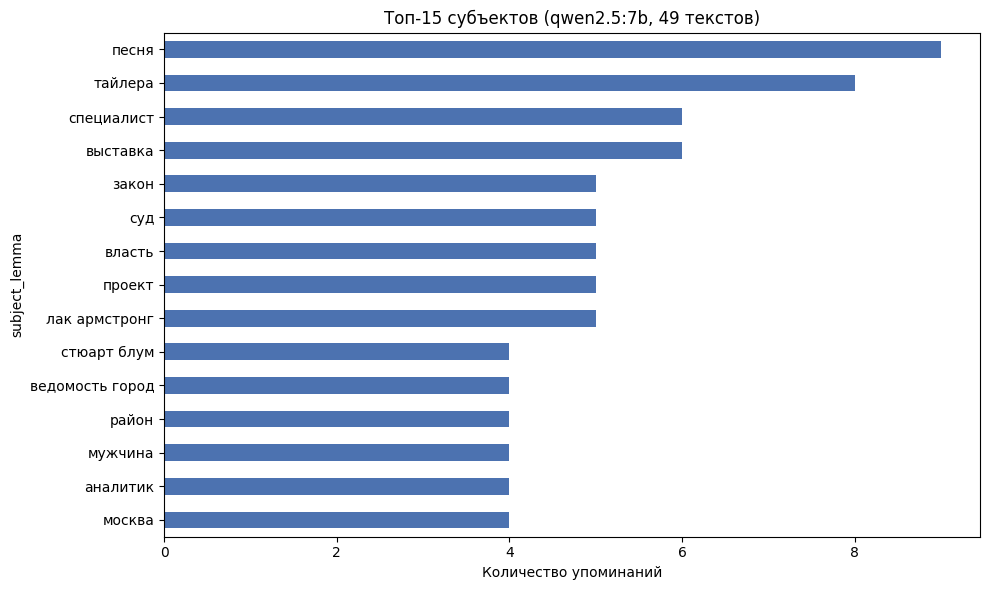

In [ ]:
import matplotlib.pyplot as plt
inf = stats[stats["informative"] == True]

fig, ax = plt.subplots(figsize=(10, 6))
inf["subject_lemma"].value_counts().head(15).plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Количество упоминаний")
ax.set_title("Топ-15 субъектов (qwen2.5:7b, 49 текстов)")
plt.tight_layout()
plt.savefig("top_subjects.png", dpi=150)
plt.show()

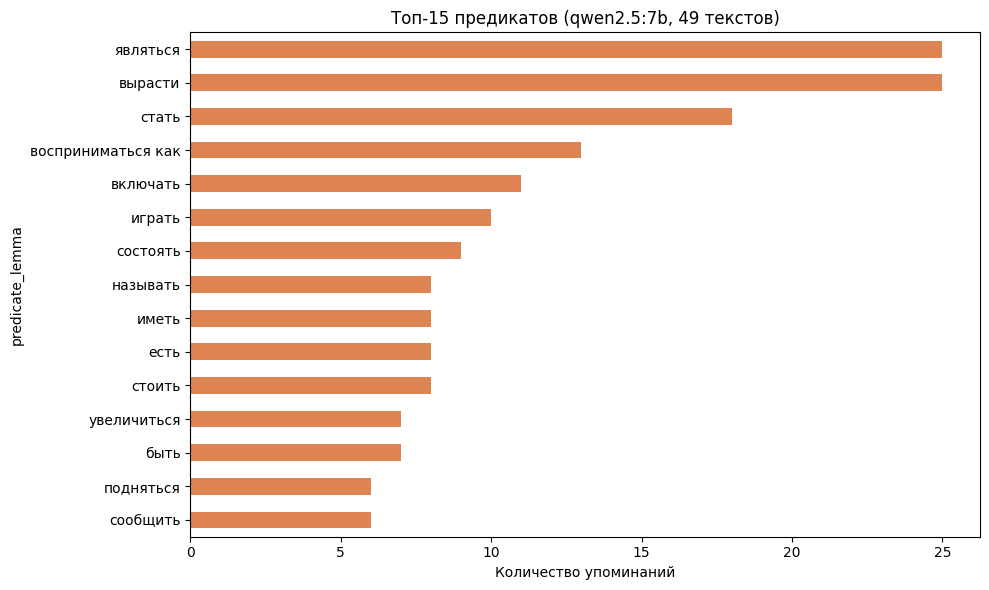

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
inf["predicate_lemma"].value_counts().head(15).plot(kind="barh", ax=ax, color="#DD8452")
ax.invert_yaxis()
ax.set_xlabel("Количество упоминаний")
ax.set_title("Топ-15 предикатов (qwen2.5:7b, 49 текстов)")
plt.tight_layout()
plt.savefig("top_predicates.png", dpi=150)
plt.show()

In [ ]:
print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)
print(f"Триплетов всего:            {len(stats)}")
print(f"Информативных:              {len(inf)}")
print(f"Уникальных субъектов:       {inf['subject_lemma'].nunique()}")
print(f"Уникальных предикатов:      {inf['predicate_lemma'].nunique()}")
print(f"Уникальных объектов:        {inf['object'].nunique()}")


ИТОГОВАЯ СВОДКА
Триплетов всего:            900
Информативных:              854
Уникальных субъектов:       696
Уникальных предикатов:      501
Уникальных объектов:        830
